In [747]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
import glob
import os

In [748]:
plays = pd.read_csv("plays.csv")
df = pd.read_csv('play_by_play_2021.csv')
epa_cols = [col for col in df.columns if 'epa' in col]
print(epa_cols)

/var/folders/gk/9_t861m96yd7zhpjkfnvqp5c0000gn/T/ipykernel_96552/1177963805.py:2: DtypeWarning: Columns (179,180,182,183,189,190,193,194,197,198,203,204,205,206,218,219,220,233,234,235,236,237,238,248,249,253,254,255,260,262,263,283,284,301) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('play_by_play_2021.csv')


['epa', 'total_home_epa', 'total_away_epa', 'total_home_rush_epa', 'total_away_rush_epa', 'total_home_pass_epa', 'total_away_pass_epa', 'air_epa', 'yac_epa', 'comp_air_epa', 'comp_yac_epa', 'total_home_comp_air_epa', 'total_away_comp_air_epa', 'total_home_comp_yac_epa', 'total_away_comp_yac_epa', 'total_home_raw_air_epa', 'total_away_raw_air_epa', 'total_home_raw_yac_epa', 'total_away_raw_yac_epa', 'qb_epa', 'xyac_epa']


In [749]:
plays.columns

Index(['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo',
       'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber',
       'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore', 'passResult',
       'penaltyYards', 'prePenaltyPlayResult', 'playResult', 'foulName1',
       'foulNFLId1', 'foulName2', 'foulNFLId2', 'foulName3', 'foulNFLId3',
       'absoluteYardlineNumber', 'offenseFormation', 'personnelO',
       'defendersInBox', 'personnelD', 'dropBackType', 'pff_playAction',
       'pff_passCoverage', 'pff_passCoverageType'],
      dtype='object')

In [750]:
plays[['playDescription', 'down', 'yardsToGo','possessionTeam','defensiveTeam','yardlineSide','yardlineNumber','playResult']]

,playDescription,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,playResult
0,(13:33) (Shotgun) T.Brady pass incomplete deep...,3,2,TB,DAL,TB,33,0
1,(13:18) (Shotgun) D.Prescott pass deep left to...,1,10,DAL,TB,DAL,2,28
2,(12:23) (Shotgun) D.Prescott pass short middle...,2,6,DAL,TB,DAL,34,5
3,(9:56) D.Prescott pass incomplete deep left to...,1,10,DAL,TB,TB,39,0
4,(9:46) (Shotgun) D.Prescott pass incomplete sh...,3,15,DAL,TB,TB,44,0
...,...,...,...,...,...,...,...,...
8552,(1:56) (Shotgun) P.Mahomes sacked at NYG 16 fo...,3,8,KC,NYG,NYG,8,-8
8553,(1:07) (Shotgun) D.Jones pass short right to E...,1,10,NYG,KC,NYG,25,3
8554,"(1:01) (No Huddle, Shotgun) D.Jones sacked at ...",2,7,NYG,KC,NYG,28,-8
8555,"(:39) (No Huddle, Shotgun) D.Jones pass incomp...",3,15,NYG,KC,NYG,20,0


In [751]:
plays

,gameId,playId,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,...,foulNFLId3,absoluteYardlineNumber,offenseFormation,personnelO,defendersInBox,personnelD,dropBackType,pff_playAction,pff_passCoverage,pff_passCoverageType
0,2021090900,97,(13:33) (Shotgun) T.Brady pass incomplete deep...,1,3,2,TB,DAL,TB,33,...,NaN,43.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"4 DL, 2 LB, 5 DB",TRADITIONAL,0,Cover-1,Man
1,2021090900,137,(13:18) (Shotgun) D.Prescott pass deep left to...,1,1,10,DAL,TB,DAL,2,...,NaN,108.0,EMPTY,"1 RB, 2 TE, 2 WR",6.0,"4 DL, 4 LB, 3 DB",TRADITIONAL,0,Cover-3,Zone
2,2021090900,187,(12:23) (Shotgun) D.Prescott pass short middle...,1,2,6,DAL,TB,DAL,34,...,NaN,76.0,SHOTGUN,"0 RB, 2 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",TRADITIONAL,0,Cover-3,Zone
3,2021090900,282,(9:56) D.Prescott pass incomplete deep left to...,1,1,10,DAL,TB,TB,39,...,NaN,49.0,SINGLEBACK,"1 RB, 2 TE, 2 WR",6.0,"4 DL, 3 LB, 4 DB",TRADITIONAL,1,Cover-3,Zone
4,2021090900,349,(9:46) (Shotgun) D.Prescott pass incomplete sh...,1,3,15,DAL,TB,TB,44,...,NaN,54.0,SHOTGUN,"1 RB, 1 TE, 3 WR",7.0,"3 DL, 4 LB, 4 DB",TRADITIONAL,0,Cover-3,Zone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8552,2021110100,4310,(1:56) (Shotgun) P.Mahomes sacked at NYG 16 fo...,4,3,8,KC,NYG,NYG,8,...,NaN,18.0,SHOTGUN,"1 RB, 1 TE, 3 WR",4.0,"1 DL, 3 LB, 7 DB",SCRAMBLE,0,Bracket,Other
8553,2021110100,4363,(1:07) (Shotgun) D.Jones pass short right to E...,4,1,10,NYG,KC,NYG,25,...,NaN,35.0,SHOTGUN,"1 RB, 1 TE, 3 WR",5.0,"4 DL, 1 LB, 6 DB",SCRAMBLE,0,Cover-2,Zone
8554,2021110100,4392,"(1:01) (No Huddle, Shotgun) D.Jones sacked at ...",4,2,7,NYG,KC,NYG,28,...,NaN,38.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"4 DL, 1 LB, 6 DB",TRADITIONAL,0,Cover-2,Zone
8555,2021110100,4411,"(:39) (No Huddle, Shotgun) D.Jones pass incomp...",4,3,15,NYG,KC,NYG,20,...,NaN,30.0,SHOTGUN,"1 RB, 1 TE, 3 WR",5.0,"4 DL, 1 LB, 6 DB",TRADITIONAL,0,Cover-2,Zone


In [752]:
df= df[['play_id', 'old_game_id', 'epa', 'comp_air_epa', 'comp_yac_epa', 'yac_epa']]

In [753]:
df['target_epa'] = df['epa'] - df['comp_air_epa']

In [754]:
df

,play_id,old_game_id,epa,comp_air_epa,comp_yac_epa,yac_epa,target_epa
0,1,2021091207,0.000000,NaN,NaN,NaN,NaN
1,40,2021091207,0.000000,0.000000,0.000000,NaN,0.000000
2,55,2021091207,-1.399805,0.000000,0.000000,NaN,-1.399805
3,76,2021091207,0.032412,-0.531589,0.564002,0.564002,0.564002
4,100,2021091207,-1.532898,0.000000,0.000000,-3.509998,-1.532898
...,...,...,...,...,...,...,...
50707,3930,2022021300,-1.215366,0.000000,0.000000,NaN,-1.215366
50708,3951,2022021300,0.000000,0.000000,0.000000,NaN,0.000000
50709,3968,2022021300,-0.623479,0.000000,0.000000,-2.416857,-0.623479
50710,3990,2022021300,0.000000,0.000000,0.000000,NaN,0.000000


In [755]:
df.rename(columns={"old_game_id": "game_id"}, errors="raise",inplace = True)

In [756]:
plays_epa_aug = plays.merge(df, left_on=['gameId', 'playId'], right_on=['game_id', 'play_id'])


In [757]:
players = pd.read_csv("players.csv")
df_pff = pd.read_csv('pffScoutingData.csv')


In [758]:
df_pff

,gameId,playId,nflId,pff_role,pff_positionLinedUp,pff_hit,pff_hurry,pff_sack,pff_beatenByDefender,pff_hitAllowed,pff_hurryAllowed,pff_sackAllowed,pff_nflIdBlockedPlayer,pff_blockType,pff_backFieldBlock
0,2021090900,97,25511,Pass,QB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021090900,97,35481,Pass Route,TE-L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021090900,97,35634,Pass Route,LWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021090900,97,39985,Pass Route,HB-R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021090900,97,40151,Pass Block,C,NaN,NaN,NaN,0.0,0.0,0.0,0.0,44955.0,SW,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188249,2021110100,4433,52507,Pass Block,LT,NaN,NaN,NaN,0.0,0.0,1.0,0.0,43338.0,PP,0.0
188250,2021110100,4433,52546,Coverage,SCBoR,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188251,2021110100,4433,52573,Pass Route,SLoWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188252,2021110100,4433,52585,Pass Rush,LEO,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [759]:
all_files = ['week' + str(i) +'.csv' for i in range(1,9)]

df_ngs = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)


# df_ngs = pd.read_csv('week1.csv')

df_ngs_lineup = df_ngs[df_ngs['frameId'] == 1][['gameId', 'playId','nflId','team','event']]


In [760]:
df_ngs_lineup.dropna(subset = 'nflId', inplace = True)
print(df_ngs[df_ngs['event'] != 'None']['event'].unique())

['ball_snap' 'autoevent_passforward' 'pass_forward' 'autoevent_ballsnap'
 'line_set' 'play_action' 'pass_arrived' 'autoevent_passinterrupted'
 'fumble' 'fumble_offense_recovered' 'qb_sack' 'run' 'man_in_motion'
 'pass_outcome_caught' 'pass_outcome_incomplete' 'pass_tipped'
 'qb_strip_sack' 'shift' 'first_contact' 'huddle_break_offense' 'lateral'
 'handoff' 'penalty_flag' 'tackle' 'dropped_pass' 'out_of_bounds']


In [761]:
rapm_df = df_ngs_lineup.merge(plays_epa_aug, left_on=['gameId', 'playId'], right_on=['gameId', 'playId'])

In [762]:
rapm_df.dropna(subset = ['gameId','playId','nflId'],inplace = True)

In [763]:
o_df = rapm_df[rapm_df['team'] == rapm_df['possessionTeam']]
d_df = rapm_df[rapm_df['team'] == rapm_df['defensiveTeam']]
#d_df 

In [764]:
#categorical data
categorical_cols = ['nflId'] 

#import pandas as pd
df_o_oh = pd.get_dummies(o_df[['gameId','playId','nflId','target_epa']], columns = categorical_cols)

p_mat_o = df_o_oh.groupby(['gameId','playId','target_epa']).sum().reset_index()
print(p_mat_o.columns[p_mat_o.iloc[0].gt(0)].tolist())
#categorical data
categorical_cols = ['nflId'] 

#import pandas as pd
df_d_oh = pd.get_dummies(d_df[['gameId','playId','nflId','target_epa']], columns = categorical_cols)

p_mat_d = df_d_oh.groupby(['gameId','playId','target_epa']).sum().reset_index()

['gameId', 'playId', 'nflId_25511.0', 'nflId_35481.0', 'nflId_35634.0', 'nflId_39985.0', 'nflId_40151.0', 'nflId_41233.0', 'nflId_42377.0', 'nflId_42404.0', 'nflId_44896.0', 'nflId_46163.0', 'nflId_52421.0']


In [765]:
p_mat_d

,gameId,playId,target_epa,nflId_33131.0,nflId_34465.0,nflId_34654.0,nflId_34777.0,nflId_35441.0,nflId_35442.0,nflId_35446.0,...,nflId_53910.0,nflId_53921.0,nflId_53930.0,nflId_53933.0,nflId_53935.0,nflId_53953.0,nflId_53957.0,nflId_53978.0,nflId_53991.0,nflId_53999.0
0,2021090900,97,-1.738529,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2021090900,137,0.296044,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2021090900,187,0.000000,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2021090900,282,-0.539422,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2021090900,349,-1.450457,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8545,2021110100,4310,-0.211321,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8546,2021110100,4363,0.035085,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8547,2021110100,4392,-0.481615,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8548,2021110100,4411,-0.142809,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [766]:
p_mat_d.iloc[:,3:]*=-1

In [767]:
p_mat_d

,gameId,playId,target_epa,nflId_33131.0,nflId_34465.0,nflId_34654.0,nflId_34777.0,nflId_35441.0,nflId_35442.0,nflId_35446.0,...,nflId_53910.0,nflId_53921.0,nflId_53930.0,nflId_53933.0,nflId_53935.0,nflId_53953.0,nflId_53957.0,nflId_53978.0,nflId_53991.0,nflId_53999.0
0,2021090900,97,-1.738529,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2021090900,137,0.296044,0,0,0,0,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2021090900,187,0.000000,0,0,0,0,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2021090900,282,-0.539422,0,0,0,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2021090900,349,-1.450457,0,0,0,0,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8545,2021110100,4310,-0.211321,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8546,2021110100,4363,0.035085,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8547,2021110100,4392,-0.481615,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8548,2021110100,4411,-0.142809,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [768]:
full_rapm = p_mat_o.merge(p_mat_d, left_on=['gameId', 'playId', 'target_epa'], right_on=['gameId', 'playId', 'target_epa'])

In [769]:
y = full_rapm['target_epa'].values
X = full_rapm.iloc[:,3:].values

In [770]:
clf = Ridge(alpha=0.33)

In [771]:
clf.fit(X, y)


Ridge(alpha=0.33)

In [772]:
clf.score(X, y)

0.18109710446277583

In [773]:
clf.get_params()

{'alpha': 0.33,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [774]:
coeffs = clf.coef_

In [775]:
coeffs_list = list(coeffs)

In [776]:
args = np.argsort(coeffs)[::-1]


In [777]:
args

array([1555,  853, 1214, ...,  339,  802,  577])

In [778]:
full_rapm.columns[3+1022]

'nflId_43330.0'

In [779]:
players[players['nflId'] == 52416]

,nflId,height,weight,birthDate,collegeName,officialPosition,displayName
1225,52416,6-3,225,1998-07-26,Clemson,ILB,Isaiah Simmons


In [780]:
def get_ranked(coeffs, args, full_rapm, players):
    player_list = []
    rank = 1
    for each in args:
        player_id = int(float(full_rapm.columns[3+each][6:]))
        snap_count = full_rapm[full_rapm.columns[3+each]].sum()
        player_name = players[players['nflId'] == player_id]['displayName'].values[0]
        player_position = players[players['nflId'] == player_id]['officialPosition'].values[0]

        player_list.append((rank,player_name,player_position, coeffs[each], abs(snap_count)) )
        rank+=1
    df = pd.DataFrame(player_list, columns=['rank', 'player','pos', 'value','snap_count'])
    return df

In [781]:
df_ranks = get_ranked(coeffs, args, full_rapm, players)

In [782]:
df_ranks[df_ranks['player'] == 'David Bakhtiari']

,rank,player,pos,value,snap_count


In [783]:
df_ranks[(df_ranks['pos']=='DE') & (df_ranks['snap_count']>=200)] 

,rank,player,pos,value,snap_count
190,191,Trey Hendrickson,DE,0.505780,237
237,238,Cameron Jordan,DE,0.433433,226
253,254,Maxx Crosby,DE,0.415590,218
433,434,Sam Hubbard,DE,0.255900,255
499,500,Emmanuel Ogbah,DE,0.198810,230
702,703,Denico Autry,DE,0.071309,215
948,949,Chase Young,DE,-0.051996,265
1037,1038,Jason Pierre-Paul,DE,-0.098335,209
1070,1071,Brian Burns,DE,-0.122185,225
1086,1087,Montez Sweat,DE,-0.134430,229


In [784]:
df_ranks[(df_ranks['pos']=='TE') & (df_ranks['snap_count']>=50)] 

,rank,player,pos,value,snap_count
86,87,Travis Kelce,TE,0.770433,303
105,106,C.J. Uzomah,TE,0.687915,216
141,142,Maxx Williams,TE,0.599198,93
181,182,Dawson Knox,TE,0.519039,166
184,185,George Kittle,TE,0.512673,125
...,...,...,...,...,...
1365,1366,T.J. Hockenson,TE,-0.351815,292
1494,1495,Jimmy Graham,TE,-0.517860,50
1510,1511,Geoff Swaim,TE,-0.549503,120
1516,1517,Foster Moreau,TE,-0.559336,117


In [785]:
df_ranks[(df_ranks['pos']=='OLB') & (df_ranks['snap_count']>=150)] 

,rank,player,pos,value,snap_count
38,39,Khalil Mack,OLB,1.007553,152
107,108,Matt Milano,OLB,0.685772,166
125,126,Alex Singleton,OLB,0.645124,188
137,138,Christian Kirksey,OLB,0.607002,228
147,148,Markus Golden,OLB,0.588759,195
167,168,Robert Quinn,OLB,0.548537,164
192,193,Haason Reddick,OLB,0.505255,226
252,253,Cory Littleton,OLB,0.416535,185
300,301,Steven Means,OLB,0.368668,180
431,432,Nick Vigil,OLB,0.260173,153


In [786]:
df_pff.columns

Index(['gameId', 'playId', 'nflId', 'pff_role', 'pff_positionLinedUp',
       'pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender',
       'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed',
       'pff_nflIdBlockedPlayer', 'pff_blockType', 'pff_backFieldBlock'],
      dtype='object')

In [787]:
print(df_pff['pff_blockType'].unique())

[nan 'SW' 'PP' 'PT' 'CL' 'PA' 'PU' 'CH' 'NB' 'BH' 'UP' 'SR' 'PR']


In [788]:
df_pff_d = df_pff[['nflId','pff_sack','pff_hurry','pff_hit']].groupby(['nflId']).sum().reset_index().sort_values(by = 'pff_sack',ascending = False)

In [789]:
df_pff_d = df_pff_d.merge(players[['nflId','displayName','officialPosition']], right_on = 'nflId',left_on = 'nflId')

In [790]:
df_pff_d['pcta'] = df_pff_d[['pff_sack']].rank(pct=True)

In [791]:
df_pff_d

,nflId,pff_sack,pff_hurry,pff_hit,displayName,officialPosition,pcta
0,44813,12.0,29.0,9.0,Myles Garrett,DE,1.000000
1,44915,10.0,29.0,6.0,Trey Hendrickson,DE,0.999404
2,46110,9.0,26.0,7.0,Harold Landry,OLB,0.998511
3,43435,9.0,27.0,7.0,Matt Judon,OLB,0.998511
4,43298,8.0,25.0,2.0,Leonard Floyd,OLB,0.997022
...,...,...,...,...,...,...,...
1674,44872,0.0,0.0,0.0,Chidobe Awuzie,CB,0.417510
1675,44870,0.0,0.0,0.0,Ethan Pocic,C,0.417510
1676,44869,0.0,0.0,0.0,Zach Cunningham,ILB,0.417510
1677,44865,0.0,0.0,0.0,Teez Tabor,FS,0.417510


In [792]:
df_pff_bpm = df_pff[['gameId', 'playId','pff_sack','pff_hurry','pff_hit','pff_beatenByDefender', ]].groupby(['gameId', 'playId']).sum().reset_index().sort_values(by = 'pff_beatenByDefender',ascending = False)

In [793]:
df_pff_bpm = df_pff_bpm.merge(df, left_on=['gameId', 'playId'], right_on=['game_id', 'play_id'])


In [794]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


df_pff_bpm.dropna(subset = ['pff_sack', 'pff_hurry','pff_hit','pff_beatenByDefender', 'target_epa'], inplace = True)
X_bpm = df_pff_bpm[['pff_sack', 'pff_hurry','pff_hit','pff_beatenByDefender']].values
y_bpm = df_pff_bpm['target_epa'].values

In [795]:
regr = linear_model.LinearRegression()
X_bpm_train = X_bpm[:-2000]
y_bpm_train = y_bpm[:-2000]
X_bpm_test = X_bpm[-2000:]
y_bpm_test = y_bpm[-2000:]
regr.fit(X_bpm_train, y_bpm_train)

y_bpm_pred = regr.predict(X_bpm_test)

print("Coefficients: \n", regr.coef_)
print("Mean squared error: %.2f" % mean_squared_error(y_bpm_test, y_bpm_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_bpm_test, y_bpm_pred))


Coefficients: 
 [-1.44975111 -0.14618505 -0.36543047 -0.01802224]
Mean squared error: 1.56
Coefficient of determination: 0.09


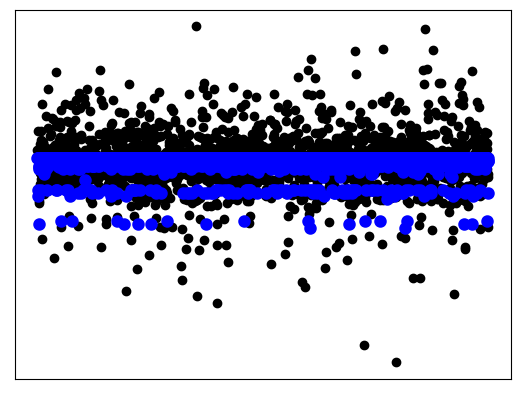

In [796]:
plt.scatter(range(2000), y_bpm_test, color="black")
plt.scatter(range(2000), y_bpm_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [797]:

df_pff_grouped = df_pff[['nflId','pff_sack','playId','pff_hurry','pff_hit','pff_beatenByDefender']].groupby(['nflId']).agg({'playId':'count', 'pff_sack': 'sum', 'pff_hurry': 'sum', 'pff_hit': 'sum', 'pff_beatenByDefender':'sum'}).reset_index()
df_pff_grouped['BPM'] =regr.predict(df_pff_grouped[['pff_sack','pff_hurry','pff_hit','pff_beatenByDefender']].values)

In [798]:
df_pff_grouped.sort_values(by= 'BPM', ascending = False, inplace = True)
df_pff_grouped = df_pff_grouped.merge(players[['nflId','displayName','officialPosition']], right_on = 'nflId',left_on = 'nflId')

In [799]:
df_pff_grouped['BPM'] = df_pff_grouped['BPM']/ df_pff_grouped['playId']


In [800]:
#df_pff_grouped
df_pff_grouped['BPM'] = df_pff_grouped['BPM'].mask(df_pff_grouped.officialPosition.isin(['CB', 'FS', 'WR','QB','TE','RB', 'HB','SS']), 0)
df_pff_grouped.drop(columns=['playId'],inplace = True)


In [801]:
full_rapm_priors = rapm_df.merge(df_pff_grouped, left_on=['nflId'], right_on=['nflId'])
full_rapm_priors

,gameId,playId,nflId,team,event,playDescription,quarter,down,yardsToGo,possessionTeam,...,comp_yac_epa,yac_epa,target_epa,pff_sack,pff_hurry,pff_hit,pff_beatenByDefender,BPM,displayName,officialPosition
0,2021090900,97,25511.0,TB,None,(13:33) (Shotgun) T.Brady pass incomplete deep...,1,3,2,TB,...,0.000000,-3.519966,-1.738529,0.0,0.0,0.0,0.0,0.000000,Tom Brady,QB
1,2021090900,410,25511.0,TB,None,(8:53) (Shotgun) T.Brady pass short middle to ...,1,2,5,TB,...,0.163605,0.163605,0.163605,0.0,0.0,0.0,0.0,0.000000,Tom Brady,QB
2,2021090900,434,25511.0,TB,None,"(8:24) (No Huddle, Shotgun) T.Brady pass incom...",1,1,10,TB,...,0.000000,-1.047600,-0.574681,0.0,0.0,0.0,0.0,0.000000,Tom Brady,QB
3,2021090900,456,25511.0,TB,None,(8:20) (Shotgun) T.Brady pass deep middle to R...,1,2,10,TB,...,0.114005,0.114005,0.114005,0.0,0.0,0.0,0.0,0.000000,Tom Brady,QB
4,2021090900,480,25511.0,TB,None,"(7:53) (No Huddle, Shotgun) T.Brady pass deep ...",1,1,10,TB,...,0.193095,0.193095,0.193095,0.0,0.0,0.0,0.0,0.000000,Tom Brady,QB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188249,2021110100,1351,46772.0,NYG,None,(12:23) (Shotgun) P.Mahomes pass short left to...,2,1,10,KC,...,0.757912,0.757912,0.757912,0.0,0.0,0.0,0.0,0.018623,Trent Harris,OLB
188250,2021110100,1396,46772.0,NYG,None,(11:09) (Shotgun) P.Mahomes pass short left to...,2,1,10,KC,...,-0.069007,-0.069007,-0.069007,0.0,0.0,0.0,0.0,0.018623,Trent Harris,OLB
188251,2021110100,1458,46772.0,NYG,None,(9:57) (Shotgun) P.Mahomes pass incomplete sho...,2,2,6,KC,...,0.000000,-2.051002,-0.774381,0.0,0.0,0.0,0.0,0.018623,Trent Harris,OLB
188252,2021110100,3392,46772.0,NYG,None,(13:56) (Shotgun) P.Mahomes pass short middle ...,4,2,7,KC,...,1.327546,1.327546,1.327546,0.0,0.0,0.0,0.0,0.018623,Trent Harris,OLB


In [802]:
o_df_prior = full_rapm_priors[full_rapm_priors['team'] == full_rapm_priors['possessionTeam']]
d_df_prior = full_rapm_priors[full_rapm_priors['team'] == full_rapm_priors['defensiveTeam']]


In [803]:
d_df_prior['BPM']= -1*d_df_prior['BPM']

/var/folders/gk/9_t861m96yd7zhpjkfnvqp5c0000gn/T/ipykernel_96552/3950675099.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d_df_prior['BPM']= -1*d_df_prior['BPM']


In [804]:
o_df_prior_BPM = o_df_prior[['nflId', 'BPM']].groupby(['nflId']).mean()
d_df_prior_BPM = d_df_prior[['nflId', 'BPM']].groupby(['nflId']).mean()
# d_df_prior_BPM.sort_values(by = 'nflId', inplace = True)
d_df_prior_BPM

,BPM
nflId,
33131.0,0.022618
34465.0,0.000000
34654.0,0.000000
34777.0,0.010457
35441.0,0.029437
...,...
53953.0,0.000000
53957.0,0.000000
53978.0,-0.008465


In [805]:
#o_df_prior_BPM[o_df_prior_BPM['BPM'] == 0]

In [806]:

categorical_cols = ['nflId'] 

#import pandas as pd
df_o_oh = pd.get_dummies(o_df_prior[['gameId','playId','nflId','target_epa']], columns = categorical_cols)

p_mat_o = df_o_oh.groupby(['gameId','playId','target_epa']).sum().reset_index()
print(p_mat_o.columns[p_mat_o.iloc[0].gt(0)].tolist())
#categorical data
categorical_cols = ['nflId'] 

#import pandas as pd
df_d_oh = pd.get_dummies(d_df_prior[['gameId','playId','nflId','target_epa']], columns = categorical_cols)

p_mat_d = df_d_oh.groupby(['gameId','playId','target_epa']).sum().reset_index()

['gameId', 'playId', 'nflId_25511.0', 'nflId_35481.0', 'nflId_35634.0', 'nflId_39985.0', 'nflId_40151.0', 'nflId_41233.0', 'nflId_42377.0', 'nflId_42404.0', 'nflId_44896.0', 'nflId_46163.0', 'nflId_52421.0']


In [807]:
print(p_mat_d.columns)
full_priors = pd.concat([o_df_prior_BPM, d_df_prior_BPM])

Index(['gameId', 'playId', 'target_epa', 'nflId_33131.0', 'nflId_34465.0',
       'nflId_34654.0', 'nflId_34777.0', 'nflId_35441.0', 'nflId_35442.0',
       'nflId_35446.0',
       ...
       'nflId_53910.0', 'nflId_53921.0', 'nflId_53930.0', 'nflId_53933.0',
       'nflId_53935.0', 'nflId_53953.0', 'nflId_53957.0', 'nflId_53978.0',
       'nflId_53991.0', 'nflId_53999.0'],
      dtype='object', length=875)


In [808]:
p_mat_d.iloc[:,3:]*=-1

In [809]:
full_rapm = p_mat_o.merge(p_mat_d, left_on=['gameId', 'playId', 'target_epa'], right_on=['gameId', 'playId', 'target_epa'])

In [810]:
full_priors = pd.concat([o_df_prior_BPM, d_df_prior_BPM])
y = full_rapm['target_epa'].values
X = full_rapm.iloc[:,3:].values
y_new = y-np.matmul(X,full_priors['BPM'].values)


In [811]:
clf = Ridge(alpha=1)
clf.fit(X, y_new)
clf.score(X, y_new)


0.17294182373486777

In [812]:
coeffs = clf.coef_
coeffs_list = list(coeffs)
args = np.argsort(coeffs)[::-1]
df_ranks = get_ranked(coeffs, args, full_rapm, players)

In [834]:
df_ol_dl = df_ranks[(df_ranks['snap_count']>=100) & ~df_ranks.pos.isin(['CB', 'FS', 'WR','QB','TE','RB', 'HB','SS'])] 

In [817]:
df_dl_rtg = df_ol_dl[df_ol_dl.pos.isin(['DE', 'MLB', 'OLB', 'ILB','DT'])]

In [818]:
df_ol_rtg = df_ol_dl[df_ol_dl.pos.isin(['C','T','G'])].reset_index(drop=True)

In [819]:
df_ol_rtg.head(10)

,rank,player,pos,value,snap_count
0,33,Jordan Mailata,T,0.790169,171
1,65,Ereck Flowers,G,0.668835,296
2,75,James Hurst,T,0.628632,126
3,116,Jon Runyan,G,0.534688,198
4,177,Jon Feliciano,G,0.415252,228
5,178,Laremy Tunsil,T,0.414144,122
6,182,Cody Ford,G,0.410438,122
7,218,Justin Britt,C,0.371892,175
8,220,Michael Jordan,G,0.371546,105
9,223,Michael Onwenu,G,0.369163,232


In [821]:
df_ol_rtg.tail(10)

,rank,player,pos,value,snap_count
172,1565,Andrew Whitworth,T,-0.524101,217
173,1591,Andrus Peat,G,-0.607731,127
174,1597,Greg Mancz,C,-0.634647,116
175,1598,Max Scharping,G,-0.642653,230
176,1607,Brandon Scherff,G,-0.662744,113
177,1618,Mitch Morse,C,-0.686847,250
178,1619,Daryl Williams,T,-0.686847,250
179,1650,Lucas Niang,T,-0.842726,232
180,1653,Wes Schweitzer,G,-0.865161,184
181,1673,Mike Remmers,T,-1.233614,108


In [825]:
df_dl_rtg.head(50)

,rank,player,pos,value,snap_count
2,3,Fred Warner,MLB,1.199209,216
23,24,Myles Jack,MLB,0.856265,170
40,41,Chris Wormley,DE,0.762614,161
57,58,Anthony Barr,OLB,0.695765,128
84,85,Tae Crowder,ILB,0.610100,243
91,92,Khalil Mack,OLB,0.595602,152
96,97,Matt Milano,OLB,0.577665,166
106,107,Folorunso Fatukasi,DT,0.562919,121
110,111,Uchenna Nwosu,OLB,0.549998,141
119,120,Alex Anzalone,ILB,0.528706,224


In [822]:
df_dl_rtg.tail(10)

,rank,player,pos,value,snap_count
1574,1575,Joey Bosa,OLB,-0.552424,194
1577,1578,Arik Armstead,DE,-0.575729,172
1582,1583,J.J. Watt,DE,-0.588852,192
1591,1592,Shaquille Leonard,MLB,-0.611816,263
1593,1594,Nick Bolton,ILB,-0.624036,158
1601,1602,David Long,ILB,-0.648127,286
1611,1612,Justin Houston,OLB,-0.672707,151
1630,1631,Logan Wilson,ILB,-0.726176,280
1656,1657,Isaiah Simmons,ILB,-0.895232,241
1669,1670,Denzel Perryman,ILB,-1.062775,212


In [835]:
df_dl_rtg[df_dl_rtg['player'] == 'Aaron Donald']

,rank,player,pos,value,snap_count
621,622,Aaron Donald,DT,0.095443,260
